# 🧬 Algoritmos Genéticos y Optimización Multiobjetivo
En problemas reales de ingeniería, economía y ciencias aplicadas, se busca **optimizar** sistemas complejos:  
- Minimizar costos 💰  
- Maximizar beneficios 📈  
- Reducir emisiones 🌱  
- Equilibrar objetivos en conflicto ⚖️  

Los métodos clásicos (Simplex, gradientes) funcionan bien cuando el problema es **lineal** o **suavemente no lineal**.  
Sin embargo, cuando se tienen:

- **Funciones no lineales**  
- **Restricciones complejas**  
- **Múltiples objetivos en conflicto**  
- **Espacios de búsqueda grandes y multimodales**

👉 Los **Algoritmos Genéticos (GA)** son más adecuados, ya que imitan la **selección natural** para encontrar soluciones de calidad sin necesidad de derivadas o linealidad.

---

## 📌 Ejemplo: Despacho Económico Multiobjetivo

En un sistema eléctrico, varios generadores deben cubrir una **demanda total de potencia**.  
El operador busca:

1. **Minimizar el costo de operación**:

$$
C(P) = \sum_{i=1}^n \big( a_i + b_i P_i + c_i P_i^2 \big)
$$

2. **Minimizar las emisiones contaminantes**:

$$
E(P) = \sum_{i=1}^n \big( \alpha_i + \beta_i P_i + \gamma_i P_i^2 \big)
$$

### Restricciones

1. **Balance de potencia**:

$$
\sum_{i=1}^n P_i = P_{demand}
$$

2. **Límites de generación**:

$$
P_{i,\min} \leq P_i \leq P_{i,\max}
$$

### Datos del ejemplo

- Generador 1: $a_1=500,\; b_1=5.3,\; c_1=0.004,\; P_{\min}=100,\; P_{\max}=400$  
- Generador 2: $a_2=400,\; b_2=5.5,\; c_2=0.006,\; P_{\min}=50,\; P_{\max}=350$  
- Generador 3: $a_3=200,\; b_3=5.8,\; c_3=0.009,\; P_{\min}=50,\; P_{\max}=300$  
- Demanda total: $P_{demand} = 850 \ \text{MW}$  

---

## 🧮 Algoritmo Genético para este problema:

1. **Codificación de individuos**  
   Cada solución se representa como un vector:  
   $[P_1, P_2, P_3]$  
   que indica la potencia generada por cada unidad.  

2. **Población inicial**  
   Se generan aleatoriamente múltiples vectores factibles que cumplen la demanda total.  

3. **Evaluación (fitness)**  
   A cada individuo se le calcula:  
   - **Costo total** $C(P)$  
   - **Emisiones** $E(P)$  
   Luego se usa una combinación ponderada para ordenar las soluciones.  

4. **Crossover (cruce)**  
   Dos soluciones padres se combinan linealmente:  

   $$
   hijo = \alpha \cdot padre_1 + (1-\alpha) \cdot padre_2
   $$

   y después se normaliza para mantener $\sum P_i = P_{demand}$.  

5. **Mutación**  
   Se selecciona un generador al azar y se le agrega una variación pequeña.  
   Luego se vuelve a ajustar para que la suma sea igual a la demanda.  

6. **Selección y elitismo**  
   - Los mejores individuos de cada generación pasan directamente a la siguiente (elitismo).  
   - El resto se genera mediante crossover y mutación.  

7. **Evolución**  
   Durante varias generaciones:  
   - El costo converge hacia valores mínimos.  
   - Aparece un **frente de Pareto** que muestra el compromiso entre costo y emisiones.  



=== RESULTADO FINAL ===
Generador 1: 399.99 MW
Generador 2: 279.23 MW
Generador 3: 170.78 MW
Costo total: 7116.51 $
Emisiones totales: 311.64 kg


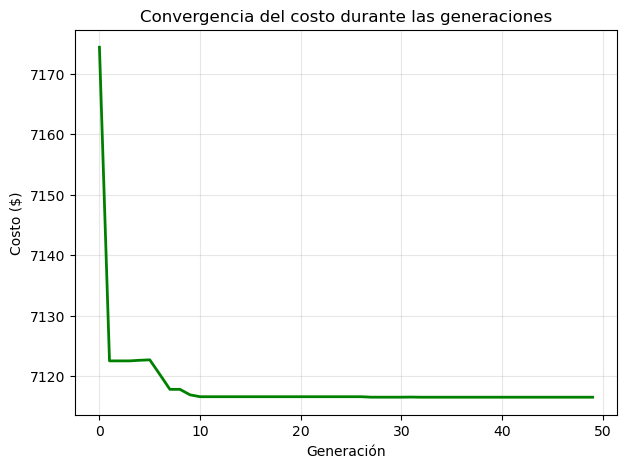

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# =====================================================
# PARÁMETROS DEL PROBLEMA (Despacho económico multiobjetivo)
# =====================================================
coef_cost = [
    (500, 5.3, 0.004, 100, 400),  # (a,b,c,Pmin,Pmax)
    (400, 5.5, 0.006, 50, 350),
    (200, 5.8, 0.009, 50, 300)
]

coef_emis = [
    (50, 0.02, 0.0005),   # (α,β,γ)
    (40, 0.025, 0.0008),
    (30, 0.03, 0.001)
]

P_demand = 850  # demanda total (MW)

# =====================================================
# FUNCIONES DE COSTO Y EMISIONES
# =====================================================
def cost(ind):
    total = 0
    for (a,b,c,pmin,pmax), Pi in zip(coef_cost, ind):
        if Pi < pmin or Pi > pmax:
            return 1e9  # penalización
        total += a + b*Pi + c*Pi**2
    if abs(sum(ind)-P_demand) > 1e-6:  # balance de potencia
        return 1e9
    return total

def emissions(ind):
    total = 0
    for (alpha,beta,gamma), Pi in zip(coef_emis, ind):
        total += alpha + beta*Pi + gamma*Pi**2
    return total

# =====================================================
# OPERADORES GENÉTICOS
# =====================================================
def crear_individuo():
    """Generar un vector factible de potencias"""
    P=[]
    remaining = P_demand
    for (a,b,c,pmin,pmax) in coef_cost[:-1]:
        Pi = random.uniform(pmin, min(pmax, remaining))
        P.append(Pi)
        remaining -= Pi
    P.append(remaining)  # el último absorbe lo restante
    return P

def crossover(p1, p2):
    alpha = random.random()
    hijo = [alpha*x + (1-alpha)*y for x,y in zip(p1,p2)]
    factor = P_demand/sum(hijo)  # normalizar para cumplir demanda
    return [h*factor for h in hijo]

def mutacion(ind):
    i = random.randint(0,2)
    ind[i] += random.uniform(-20,20)
    factor = P_demand/sum(ind)
    return [max(0, h*factor) for h in ind]

# =====================================================
# ALGORITMO GENÉTICO
# =====================================================
POP = 80   # tamaño población
GEN = 50   # generaciones
poblacion = [crear_individuo() for _ in range(POP)]

hist_pareto = []  # trayectoria de mejor solución
hist_cost = []    # evolución del costo

for g in range(GEN):
    poblacion.sort(key=lambda ind: cost(ind)+emissions(ind))  # selección por suma ponderada
    mejor = poblacion[0]
    hist_pareto.append((cost(mejor), emissions(mejor)))
    hist_cost.append(cost(mejor))

    nueva_pob = poblacion[:10]  # elitismo
    while len(nueva_pob)<POP:
        p1,p2 = random.sample(poblacion[:30], 2)
        hijo = crossover(p1,p2)
        if random.random()<0.3:
            hijo = mutacion(hijo)
        nueva_pob.append(hijo)
    poblacion = nueva_pob

# =====================================================
# RESULTADO FINAL
# =====================================================
best = poblacion[0]
best_cost = cost(best)
best_emis = emissions(best)

print("=== RESULTADO FINAL ===")
for i, Pi in enumerate(best, start=1):
    print(f"Generador {i}: {Pi:.2f} MW")
print(f"Costo total: {best_cost:.2f} $")
print(f"Emisiones totales: {best_emis:.2f} kg")

# =====================================================
# 1) ANIMACIÓN CON FLECHAS (costo vs emisiones)
# =====================================================
fig1, ax1 = plt.subplots(figsize=(7,6))

def update(frame):
    ax1.clear()
    xs = [p[0] for p in hist_pareto[:frame+1]]
    ys = [p[1] for p in hist_pareto[:frame+1]]

    ax1.plot(xs, ys, 'o-', color="blue", alpha=0.7)

    # flecha de dirección
    if frame > 0:
        x0, y0 = hist_pareto[frame-1]
        x1, y1 = hist_pareto[frame]
        ax1.annotate("",
                     xy=(x1, y1), xytext=(x0, y0),
                     arrowprops=dict(arrowstyle="->", color="red", lw=2))

    ax1.set_title(f"Evolución multiobjetivo (gen {frame})")
    ax1.set_xlabel("Costo ($)")
    ax1.set_ylabel("Emisiones (kg)")
    ax1.grid(alpha=0.3)

ani = FuncAnimation(fig1, update, frames=GEN, interval=400, repeat=False)
plt.close(fig1)  # evitar gráfico estático
display(HTML(ani.to_jshtml()))

# =====================================================
# 2) GRÁFICO DE CONVERGENCIA DEL COSTO
# =====================================================
plt.figure(figsize=(7,5))
plt.plot(hist_cost, color="green", lw=2)
plt.title("Convergencia del costo durante las generaciones")
plt.xlabel("Generación")
plt.ylabel("Costo ($)")
plt.grid(alpha=0.3)
plt.show()
